# SVM Optimisation and PEGASOS

## Learning Objectives

1. **Contrast** QP (quadratic programming) solvers with SGD for SVM training
2. **State** the PEGASOS objective: $f(\mathbf{w}) = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{m}\sum_i \max\{0, 1 - y_i\langle\mathbf{w},\mathbf{x}_i\rangle\}$
3. **Derive** the PEGASOS update: subgradient step + projection onto $\|\mathbf{w}\| \leq 1/\sqrt{\lambda}$ ball
4. **State** the PEGASOS convergence guarantee: $\tilde{O}(n/\delta\lambda\varepsilon)$ examples to reach $\varepsilon$-suboptimality
5. **Explain** the kernel trick in SGD: expand $\mathbf{w} = \sum_i \alpha_i \phi(\mathbf{x}_i)$, update dual coefficients
6. **Implement** PEGASOS and compare convergence with standard subgradient descent


## Problem Statement

### SVM Primal Objective

$$f(\mathbf{w}) = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{m}\sum_{i=1}^m \ell(y_i \langle\mathbf{w}, \mathbf{x}_i\rangle), \quad \ell(z) = \max(0, 1-z)$$

where $\lambda = 1/(mC)$. The regulariser is $\lambda$-strongly convex, making the problem well-conditioned.

### PEGASOS Algorithm (Shalev-Shwartz et al., ICML 2007)

**PEGASOS** = Primal Estimated sub-GrAdient SOlver for SVM. Key insight: the regulariser $\lambda/2 \|\mathbf{w}\|^2$ implies the optimal solution satisfies $\|\mathbf{w}^*\| \leq 1/\sqrt{\lambda}$. We can project onto this ball after each step.

Update at iteration $t$ (mini-batch $A_t \subset [m]$, $|A_t| = k$):

1. $\eta_t = 1/(\lambda t)$ &nbsp;&nbsp;(decreasing step size)
2. $A_t^+ = \{i \in A_t : y_i \langle\mathbf{w}_t, \mathbf{x}_i\rangle < 1\}$ &nbsp;&nbsp;(active hinge)
3. $\mathbf{w}_{t+1/2} = (1 - \eta_t\lambda)\mathbf{w}_t + \frac{\eta_t}{k}\sum_{i \in A_t^+} y_i \mathbf{x}_i$
4. $\mathbf{w}_{t+1} = \min\left(1, \frac{1/\sqrt{\lambda}}{\|\mathbf{w}_{t+1/2}\|}\right) \mathbf{w}_{t+1/2}$ &nbsp;&nbsp;(projection)

**Convergence**: after $T = O(1/(\lambda\varepsilon))$ iterations, $f(\bar{\mathbf{w}}) - f(\mathbf{w}^*) \leq \varepsilon$ where $\bar{\mathbf{w}} = (1/T)\sum_t \mathbf{w}_t$.

### Kernel PEGASOS

With a kernel $K(\mathbf{x},\mathbf{x}') = \phi(\mathbf{x})\cdot\phi(\mathbf{x}')$, represent $\mathbf{w}_t = \sum_{j} \alpha_{t,j} y_j \phi(\mathbf{x}_j)$. The inner product becomes:
$$\langle\mathbf{w}_t, \phi(\mathbf{x}_i)\rangle = \sum_j \alpha_{t,j} y_j K(\mathbf{x}_j, \mathbf{x}_i)$$


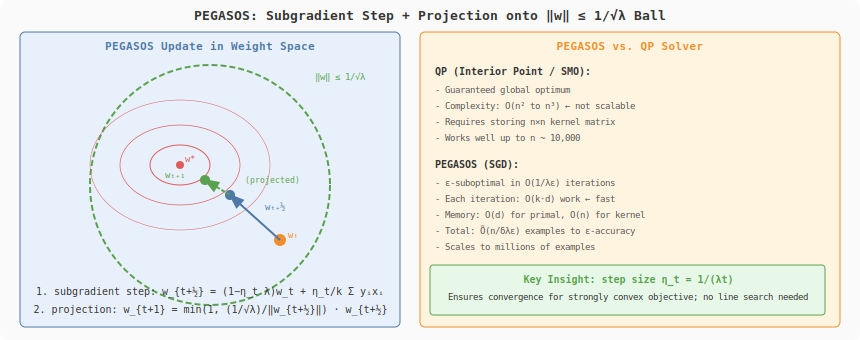

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="340" font-family="monospace" font-size="11">
  <rect width="860" height="340" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">PEGASOS: Subgradient Step + Projection onto ‖w‖ ≤ 1/√λ Ball</text>

  <!-- Weight space diagram -->
  <rect x="20" y="32" width="380" height="295" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="210" y="50" text-anchor="middle" fill="#4e79a7" font-weight="bold">PEGASOS Update in Weight Space</text>

  <!-- Feasible ball -->
  <circle cx="210" cy="185" r="120" fill="none" stroke="#59a14f" stroke-width="2" stroke-dasharray="6,3"/>
  <text x="315" y="80" fill="#59a14f" font-size="9">‖w‖ ≤ 1/√λ</text>

  <!-- Contours of SVM objective (ellipses centered at w*) -->
  <ellipse cx="180" cy="165" rx="30" ry="20" fill="none" stroke="#e05c5c" stroke-width="1"/>
  <ellipse cx="180" cy="165" rx="60" ry="40" fill="none" stroke="#e05c5c" stroke-width="0.7"/>
  <ellipse cx="180" cy="165" rx="90" ry="65" fill="none" stroke="#e05c5c" stroke-width="0.5"/>
  <circle cx="180" cy="165" r="4" fill="#e05c5c"/>
  <text x="185" y="162" fill="#e05c5c" font-size="9">w*</text>

  <!-- Current point -->
  <circle cx="280" cy="240" r="6" fill="#f28e2b"/>
  <text x="288" y="238" fill="#f28e2b" font-size="9">wₜ</text>

  <!-- Subgradient step -->
  <line x1="280" y1="240" x2="230" y2="195" stroke="#4e79a7" stroke-width="2" marker-end="url(#arr)"/>
  <text x="265" y="210" fill="#4e79a7" font-size="9">wₜ₊½</text>
  <circle cx="230" cy="195" r="5" fill="#4e79a7"/>

  <!-- Projection -->
  <line x1="230" y1="195" x2="205" y2="180" stroke="#59a14f" stroke-width="2" stroke-dasharray="4,2" marker-end="url(#arr2)"/>
  <circle cx="205" cy="180" r="5" fill="#59a14f"/>
  <text x="165" y="178" fill="#59a14f" font-size="9">wₜ₊₁</text>
  <text x="245" y="183" fill="#59a14f" font-size="8">(projected)</text>

  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#4e79a7"/></marker>
        <marker id="arr2" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#59a14f"/></marker></defs>

  <text x="210" y="295" text-anchor="middle" fill="#333" font-size="10">1. subgradient step: w_{t+½} = (1−η_t λ)w_t + η_t/k Σ yᵢxᵢ</text>
  <text x="210" y="313" text-anchor="middle" fill="#333" font-size="10">2. projection: w_{t+1} = min(1, (1/√λ)/‖w_{t+½}‖) · w_{t+½}</text>

  <!-- Convergence / QP comparison -->
  <rect x="420" y="32" width="420" height="295" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="630" y="50" text-anchor="middle" fill="#f28e2b" font-weight="bold">PEGASOS vs. QP Solver</text>

  <text x="435" y="75" fill="#333" font-size="10" font-weight="bold">QP (Interior Point / SMO):</text>
  <text x="435" y="93" fill="#555" font-size="9">- Guaranteed global optimum</text>
  <text x="435" y="109" fill="#555" font-size="9">- Complexity: O(n² to n³)   ← not scalable</text>
  <text x="435" y="125" fill="#555" font-size="9">- Requires storing n×n kernel matrix</text>
  <text x="435" y="141" fill="#555" font-size="9">- Works well up to n ~ 10,000</text>

  <text x="435" y="168" fill="#333" font-size="10" font-weight="bold">PEGASOS (SGD):</text>
  <text x="435" y="186" fill="#555" font-size="9">- ε-suboptimal in O(1/λε) iterations</text>
  <text x="435" y="202" fill="#555" font-size="9">- Each iteration: O(k·d) work  ← fast</text>
  <text x="435" y="218" fill="#555" font-size="9">- Memory: O(d) for primal, O(n) for kernel</text>
  <text x="435" y="234" fill="#555" font-size="9">- Total: Õ(n/δλε) examples to ε-accuracy</text>
  <text x="435" y="250" fill="#555" font-size="9">- Scales to millions of examples</text>

  <rect x="430" y="265" width="395" height="50" rx="3" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="628" y="283" text-anchor="middle" fill="#59a14f" font-size="10" font-weight="bold">Key Insight: step size η_t = 1/(λt)</text>
  <text x="628" y="300" text-anchor="middle" fill="#333" font-size="9">Ensures convergence for strongly convex objective; no line search needed</text>
</svg>
'''
display(SVG(svg))


## Derivation

### PEGASOS Step Size

For a $\lambda$-strongly convex function, the optimal decaying step size is $\eta_t = 1/(\lambda t)$. This leads to the $(1-\eta_t\lambda)$ shrinkage factor in the update:
$$\mathbf{w}_{t+1/2} = \underbrace{(1-\eta_t\lambda)}_{1-1/t}\mathbf{w}_t + \frac{\eta_t}{k}\sum_{i \in A_t^+} y_i \mathbf{x}_i$$

### Why Projection?

For the SVM primal, the optimal solution satisfies $\|\mathbf{w}^*\| \leq 1/\sqrt{\lambda}$ (follows from KKT conditions and strong convexity). Projecting onto this ball after each step never moves away from the optimal, but keeps iterates bounded — which tightens the convergence bound.

### Convergence Proof Sketch

For strongly convex $f$ with $\lambda$-strong convexity and $G$-bounded gradients:
$$f(\bar{\mathbf{w}}) - f(\mathbf{w}^*) \leq \frac{G^2(1+\log T)}{2\lambda T}$$

Since $G = O(\|\mathbf{x}\|_2)$ (bounded by feature norm), and $\bar{\mathbf{w}} = (1/T)\sum_t \mathbf{w}_t$.

### Kernel PEGASOS

Represent $\mathbf{w}_t = \frac{1}{\lambda t}\sum_{j} \alpha_{t,j} y_j \phi(\mathbf{x}_j)$. The update on $\boldsymbol{\alpha}$ is:
$$\alpha_{t+1,j} = (1-1/t)\alpha_{t,j} + \mathbf{1}[j \in A_t^+]$$

Score computation: $\langle\mathbf{w}_t, \phi(\mathbf{x}_i)\rangle = \frac{1}{\lambda t}\sum_j \alpha_{t,j} y_j K(\mathbf{x}_j, \mathbf{x}_i)$ — $O(n \cdot k)$ per step.


In [2]:
import numpy as np


def pegasos(X, y, lam, T, k=1, seed=0):
    """
    PEGASOS: Primal Estimated subGrAdient SOlver for SVM.

    Parameters
    ----------
    X   : (n, d) feature matrix
    y   : (n,) labels in {-1, +1}
    lam : regularisation parameter (= 1/(m*C))
    T   : number of iterations
    k   : mini-batch size

    Returns
    -------
    w      : final weight vector
    w_avg  : averaged iterate (for convergence guarantee)
    losses : objective value at each iteration
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w      = np.zeros(d)
    w_sum  = np.zeros(d)
    losses = []

    for t in range(1, T+1):
        eta = 1.0 / (lam * t)

        # Sample mini-batch
        idx = rng.choice(n, size=k, replace=False)
        Xb, yb = X[idx], y[idx]

        # Active set: hinge loss is active
        scores = yb * (Xb @ w)
        active = scores < 1

        # Update
        w = (1 - eta * lam) * w
        if active.any():
            w += (eta / k) * (yb[active, None] * Xb[active]).sum(axis=0)

        # Project onto ball of radius 1/sqrt(lam)
        norm_w = np.linalg.norm(w)
        max_norm = 1.0 / np.sqrt(lam)
        if norm_w > max_norm:
            w = w * (max_norm / norm_w)

        w_sum += w

        # Compute objective
        margin = y * (X @ w)
        obj = 0.5 * lam * np.dot(w, w) + np.maximum(0, 1 - margin).mean()
        losses.append(obj)

    w_avg = w_sum / T
    return w, w_avg, losses


def subgradient_svm(X, y, lam, T, lr0=0.1, seed=0):
    """Basic subgradient descent (no projection) for comparison."""
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = np.zeros(d)
    losses = []
    for t in range(1, T+1):
        eta = lr0 / np.sqrt(t)
        scores = y * (X @ w)
        active = scores < 1
        g = lam * w - (y[active, None] * X[active]).sum(axis=0) / n
        w -= eta * g
        obj = 0.5 * lam * np.dot(w,w) + np.maximum(0, 1-y*(X@w)).mean()
        losses.append(obj)
    return w, losses


# ── Benchmark on linearly separable data ──────────────────────────────────────
rng = np.random.default_rng(0)
n_train = 500
X = rng.standard_normal((n_train, 2))
y = np.where(X[:,0] - X[:,1] > 0.3, 1, -1)

lam = 0.01
T   = 1000

w_peg, w_peg_avg, losses_peg = pegasos(X, y, lam, T, k=1)
w_sub, losses_sub = subgradient_svm(X, y, lam, T)

acc_peg = (np.sign(X @ w_peg)     == y).mean()
acc_avg = (np.sign(X @ w_peg_avg) == y).mean()
acc_sub = (np.sign(X @ w_sub)     == y).mean()

print(f"PEGASOS (last iterate):    acc={acc_peg:.2%}, obj={losses_peg[-1]:.4f}")
print(f"PEGASOS (averaged):        acc={acc_avg:.2%}, obj={0.5*lam*np.dot(w_peg_avg,w_peg_avg)+np.maximum(0,1-y*(X@w_peg_avg)).mean():.4f}")
print(f"Subgradient (no proj):     acc={acc_sub:.2%}, obj={losses_sub[-1]:.4f}")
print(f"\nPEGASOS ‖w‖={np.linalg.norm(w_peg):.4f},  bound 1/√λ={1/np.sqrt(lam):.4f}")


PEGASOS (last iterate):    acc=92.80%, obj=0.2125
PEGASOS (averaged):        acc=93.40%, obj=0.2121
Subgradient (no proj):     acc=93.60%, obj=0.2596

PEGASOS ‖w‖=2.9470,  bound 1/√λ=10.0000


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Convergence comparison
axes[0].plot(losses_peg, color='#4e79a7', lw=1.5, label='PEGASOS (k=1)')
axes[0].plot(losses_sub, color='#e05c5c', lw=1.5, linestyle='--', label='Subgradient (no proj)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('SVM Objective')
axes[0].set_title('PEGASOS vs. Subgradient Convergence', fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Mini-batch size effect
for k in [1, 10, 50]:
    _, _, l_k = pegasos(X, y, lam, T, k=k)
    axes[1].plot(l_k, lw=1.5, label=f'k={k}')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('SVM Objective')
axes[1].set_title('Effect of Mini-Batch Size on Convergence', fontsize=10)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

fig.tight_layout()
plt.savefig('pegasos.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")


Figure saved.


/tmp/ipykernel_305804/3266387194.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
